# Phase 1: Feature Engineering and Baseline Modeling
**Capstone Project:** Population & Economic Dynamics in Puerto Rico

As outlined in our predictive framework, this notebook establishes the data foundation and baseline performance metrics. Before deploying complex non-linear models (like Random Forest), we must first clean the data, engineer domain-specific features, and train a straightforward baseline model (Ordinary Least Squares Linear Regression) to serve as our benchmark.

### The Predictive Pipeline


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from math import radians, cos, sin, asin, sqrt

# Scikit-Learn modules
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Helper function for geographic distance
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon, dlat = lon2 - lon1, lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * asin(sqrt(a)) * 6371 # Radius of earth in km

## 1. Data Ingestion & Preprocessing
We begin by loading our consolidated master dataset, which includes Census population estimates, vital statistics (births/deaths), employer establishments, CDC Social Vulnerability Index (SVI) metrics, and historical hurricane tracks.


In [2]:

# Load the master profile
df = pd.read_csv('../data/puerto_rico_master_profile.csv')

# Standardize municipio names
df['municipio'] = df['municipio'].str.replace(' Municipio', '', case=False).str.strip()

# Sort for time-series operations
df = df.sort_values(by=['municipio', 'year']).reset_index(drop=True)

# Add Municipality Centroids for spatial matching
municipio_coords = {
    'Adjuntas': (18.1627, -66.7222), 'Aguada': (18.3605, -67.1882), 'Aguadilla': (18.4275, -67.1541),
    'Aguas Buenas': (18.2572, -66.1031), 'Aibonito': (18.1408, -66.2663), 'Añasco': (18.2827, -67.1399),
    'Arecibo': (18.4724, -66.7157), 'Arroyo': (17.9658, -66.0614), 'Barceloneta': (18.4505, -66.5385),
    'Barranquitas': (18.1861, -66.3061), 'Bayamón': (18.3808, -66.1557), 'Cabo Rojo': (18.0866, -67.1457),
    'Caguas': (18.2325, -66.0391), 'Camuy': (18.4838, -66.8450), 'Canóvanas': (18.3791, -65.9011),
    'Carolina': (18.3808, -65.9574), 'Cataño': (18.4388, -66.1182), 'Cayey': (18.1119, -66.1663),
    'Ceiba': (18.2633, -65.6474), 'Ciales': (18.3361, -66.4688), 'Cidra': (18.1758, -66.1617),
    'Coamo': (18.0855, -66.3579), 'Comerío': (18.2183, -66.2257), 'Corozal': (18.3411, -66.3161),
    'Culebra': (18.3030, -65.3010), 'Dorado': (18.4588, -66.2677), 'Fajardo': (18.3258, -65.6524),
    'Florida': (18.3625, -66.5614), 'Guánica': (17.9716, -66.9080), 'Guayama': (17.9741, -66.1100),
    'Guayanilla': (18.0130, -66.7919), 'Guaynabo': (18.3580, -66.1111), 'Gurabo': (18.2544, -65.9728),
    'Hatillo': (18.4863, -66.8250), 'Hormigueros': (18.1397, -67.1274), 'Humacao': (18.1497, -65.8274),
    'Isabela': (18.5011, -67.0247), 'Jayuya': (18.2186, -66.5916), 'Juana Díaz': (18.0525, -66.5064),
    'Juncos': (18.2275, -65.9211), 'Lajas': (18.0497, -67.0594), 'Lares': (18.2947, -66.8771),
    'Las Marías': (18.2514, -66.9922), 'Las Piedras': (18.1827, -65.8661), 'Loíza': (18.4330, -65.8797),
    'Luquillo': (18.3725, -65.7166), 'Manatí': (18.4274, -66.4922), 'Maricao': (18.1808, -66.9799),
    'Maunabo': (18.0072, -65.8994), 'Mayagüez': (18.2011, -67.1397), 'Moca': (18.3947, -67.1131),
    'Morovis': (18.3258, -66.4053), 'Naguabo': (18.2119, -65.7350), 'Naranjito': (18.3008, -66.2447),
    'Orocovis': (18.2269, -66.4411), 'Patillas': (18.0066, -66.0161), 'Peñuelas': (18.0622, -66.7219),
    'Ponce': (18.0111, -66.6141), 'Quebradillas': (18.4738, -66.9385), 'Rincón': (18.3403, -67.2500),
    'Río Grande': (18.3794, -65.8311), 'Sabana Grande': (18.0777, -66.9605), 'Salinas': (17.9775, -66.2974),
    'San Germán': (18.0816, -67.0400), 'San Juan': (18.4655, -66.1057), 'San Lorenzo': (18.1894, -65.9611),
    'San Sebastián': (18.3372, -66.9905), 'Santa Isabel': (17.9666, -66.4050), 'Toa Alta': (18.3883, -66.2485),
    'Toa Baja': (18.4438, -66.2591), 'Trujillo Alto': (18.3547, -66.0072), 'Utuado': (18.2655, -66.7005),
    'Vega Alta': (18.4119, -66.3314), 'Vega Baja': (18.4438, -66.3874), 'Vieques': (18.1261, -65.4400),
    'Villalba': (18.1275, -66.4925), 'Yabucoa': (18.0505, -65.8794), 'Yauco': (18.0350, -66.8499)
}
df['lat'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[0])
df['lon'] = df['municipio'].map(lambda x: municipio_coords.get(x, (None, None))[1])

### **1.1 Integrating Social Shocks: Crime Data (2010-2025)**

While natural disasters act as acute environmental shocks, crime acts as a chronic "social shock" that serves as a major push factor for out-migration. To test this hypothesis, we integrate 16 years of municipality-level crime data from the Puerto Rico Police Bureau.

**Data Engineering Steps:**
1. **Consolidation**: Merging 16 separate annual Excel sheets into a single longitudinal format.
2. **Standardization**: Normalizing `municipio` names and removing duplicate columns to allow for a clean `LEFT JOIN` with our master demographic profile.
3. **Numeric Cleaning**: Handling thousand-separator inconsistencies in raw police data (e.g., converting '1.154' to 1154).

In [3]:
import pandas as pd
import numpy as np

def load_crime_data_fixed(file_path):
    xl = pd.ExcelFile(file_path)
    all_years = []
    
    for sheet_name in xl.sheet_names:
        if not sheet_name.isdigit(): continue
            
        df_year = xl.parse(sheet_name)
        
        # 1. Standardize headers: lowercase and strip spaces
        df_year.columns = [str(c).strip().lower() for c in df_year.columns]
        
        # 2. Fix 'municipio' column - find the first column containing 'mun'
        mun_cols = [c for c in df_year.columns if 'mun' in c]
        if mun_cols:
            df_year = df_year.rename(columns={mun_cols[0]: 'municipio'})
        
        # 3. CRITICAL: Drop any duplicate columns (e.g., if there were two 'municipio' columns)
        df_year = df_year.loc[:, ~df_year.columns.duplicated()]
        
        # 4. Standardize Crime Names (Handle 'total' vs 'total ')
        df_year = df_year.rename(columns={'total ': 'total'})
        
        # 5. Clean numeric strings (remove '.' thousand separators)
        numeric_cols = ['murder', 'robbery', 'burglary', 'larceny / theft', 'total']
        for col in numeric_cols:
            if col in df_year.columns:
                df_year[col] = df_year[col].astype(str).str.replace('.', '', regex=False).str.replace(',', '', regex=False)
                df_year[col] = pd.to_numeric(df_year[col], errors='coerce').fillna(0).astype(int)
        
        df_year['year'] = int(sheet_name)
        all_years.append(df_year[['municipio', 'year'] + [c for c in numeric_cols if c in df_year.columns]])

    return pd.concat(all_years, ignore_index=True)

# --- EXECUTION ---
crime_path = '../data/crime/PR_Crime_Summary_2010_2025.xlsx'
crime_df = load_crime_data_fixed(crime_path)

# Prepare main df
df.columns = df.columns.str.lower().str.strip()

# Create clean join keys
df['mun_key'] = df['municipio'].astype(str).str.upper().str.strip().str.replace(' MUNICIPIO', '', regex=False)
crime_df['mun_key'] = crime_df['municipio'].astype(str).str.upper().str.strip()

# Final Merge
df = df.merge(crime_df.drop(columns=['municipio']), on=['mun_key', 'year'], how='left').fillna(0)
df.drop(columns=['mun_key'], inplace=True)

print("Successfully merged crime factors!")

Successfully merged crime factors!


In [4]:

# --- IMPROVED DISASTER FEATURE ENGINEERING (HURRICANES + EARTHQUAKES) ---
def get_distances_vectorized(target_lat, target_lon, lats, lons):
    # Great-circle distance in km (vectorized)
    target_lat, target_lon = np.radians(target_lat), np.radians(target_lon)
    lats, lons = np.radians(lats), np.radians(lons)
    dlat, dlon = lats - target_lat, lons - target_lon
    a = np.sin(dlat / 2) ** 2 + np.cos(target_lat) * np.cos(lats) * np.sin(dlon / 2) ** 2
    return 2 * np.arcsin(np.sqrt(a)) * 6371

# -----------------------------
# 1. Load hurricane tracks
# -----------------------------
hurricane_tracks = pd.read_csv('../data/natural_disasters/caribbean_hurricane_tracks_2010_2025.csv')

hurricane_numeric_cols = [
    'Lat', 'Lon', 'Wind_Knots', 'Pressure_mb',
    'R34_NE', 'R34_SE', 'R34_SW', 'R34_NW',
    'R64_NE', 'R64_SE', 'R64_SW', 'R64_NW'
]
for col in hurricane_numeric_cols:
    if col in hurricane_tracks.columns:
        hurricane_tracks[col] = pd.to_numeric(hurricane_tracks[col], errors='coerce')

# Convert wind-field radii from nautical miles to km
NM_TO_KM = 1.852
hurricane_tracks['R34_max_km'] = hurricane_tracks[['R34_NE', 'R34_SE', 'R34_SW', 'R34_NW']].max(axis=1) * NM_TO_KM
hurricane_tracks['R64_max_km'] = hurricane_tracks[['R64_NE', 'R64_SE', 'R64_SW', 'R64_NW']].max(axis=1) * NM_TO_KM

# Keep years aligned to panel
hurricane_tracks = hurricane_tracks[
    hurricane_tracks['Year'].between(pd.to_numeric(df['year'], errors='coerce').min(),
                                     pd.to_numeric(df['year'], errors='coerce').max())
].copy()

tracks_by_year = {year: grp.copy() for year, grp in hurricane_tracks.groupby('Year')}

# -----------------------------
# 2. Load earthquakes
# -----------------------------
with open('../data/natural_disasters/puerto_rico_earthquakes.json') as f:
    eq_data = pd.DataFrame(json.load(f))

# Coerce expected fields
eq_data['date'] = pd.to_datetime(eq_data['date'], errors='coerce')
eq_data['year'] = eq_data['date'].dt.year
for col in ['mag', 'latitude', 'longitude']:
    eq_data[col] = pd.to_numeric(eq_data[col], errors='coerce')

eq_data = eq_data.dropna(subset=['year', 'mag', 'latitude', 'longitude']).copy()
eq_by_year = {year: grp.copy() for year, grp in eq_data.groupby('year')}

# -----------------------------
# 3. Hurricane summary features
# -----------------------------
def summarize_hurricanes_for_row(row):
    yr = row['year']
    lat = row['lat']
    lon = row['lon']

    if pd.isna(lat) or pd.isna(lon) or yr not in tracks_by_year:
        return pd.Series({
            'max_wind_knots': 0.0,
            'storm_count_100km': 0,
            'wind_exposure_score_100km': 0.0,
            'ts_windfield_hit': 0,
            'hurricane_windfield_hit': 0,
            'major_hurricane_count_100km': 0,
            'min_storm_distance_km': np.nan
        })

    storms = tracks_by_year[yr].copy()
    storms['distance_km'] = get_distances_vectorized(lat, lon, storms['Lat'].values, storms['Lon'].values)

    nearby = storms[storms['distance_km'] <= 100].copy()

    ts_hit = int((storms['distance_km'] <= storms['R34_max_km']).fillna(False).any())
    hurr_hit = int((storms['distance_km'] <= storms['R64_max_km']).fillna(False).any())

    if nearby.empty:
        return pd.Series({
            'max_wind_knots': 0.0,
            'storm_count_100km': 0,
            'wind_exposure_score_100km': 0.0,
            'ts_windfield_hit': ts_hit,
            'hurricane_windfield_hit': hurr_hit,
            'major_hurricane_count_100km': 0,
            'min_storm_distance_km': float(storms['distance_km'].min()) if len(storms) else np.nan
        })

    storm_count = nearby['Storm_ID'].nunique()
    max_wind = float(nearby['Wind_Knots'].max())
    wind_exposure = float((nearby['Wind_Knots'] / (nearby['distance_km'] + 10)).sum())
    storm_peak = nearby.groupby('Storm_ID')['Wind_Knots'].max()
    major_count = int((storm_peak >= 96).sum())
    min_dist = float(nearby['distance_km'].min())

    return pd.Series({
        'max_wind_knots': max_wind,
        'storm_count_100km': storm_count,
        'wind_exposure_score_100km': wind_exposure,
        'ts_windfield_hit': ts_hit,
        'hurricane_windfield_hit': hurr_hit,
        'major_hurricane_count_100km': major_count,
        'min_storm_distance_km': min_dist
    })

# -----------------------------
# 4. Earthquake summary features
# -----------------------------
def summarize_earthquakes_for_row(row):
    yr = row['year']
    lat = row['lat']
    lon = row['lon']

    if pd.isna(lat) or pd.isna(lon) or yr not in eq_by_year:
        return pd.Series({
            'max_seismic_mag': 0.0,
            'quake_count_50km': 0,
            'seismic_exposure_score_50km': 0.0,
            'min_quake_distance_km': np.nan
        })

    year_eq = eq_by_year[yr].copy()
    # Keep meaningful tremors for demographic shock; 4.0+ like your original notebook
    year_eq = year_eq[year_eq['mag'] >= 4.0].copy()

    if year_eq.empty:
        return pd.Series({
            'max_seismic_mag': 0.0,
            'quake_count_50km': 0,
            'seismic_exposure_score_50km': 0.0,
            'min_quake_distance_km': np.nan
        })

    year_eq['distance_km'] = get_distances_vectorized(lat, lon, year_eq['latitude'].values, year_eq['longitude'].values)
    nearby = year_eq[year_eq['distance_km'] <= 50].copy()

    if nearby.empty:
        return pd.Series({
            'max_seismic_mag': 0.0,
            'quake_count_50km': 0,
            'seismic_exposure_score_50km': 0.0,
            'min_quake_distance_km': float(year_eq['distance_km'].min())
        })

    max_mag = float(nearby['mag'].max())
    quake_count = int(len(nearby))
    seismic_exposure = float((nearby['mag'] / (nearby['distance_km'] + 5)).sum())
    min_dist = float(nearby['distance_km'].min())

    return pd.Series({
        'max_seismic_mag': max_mag,
        'quake_count_50km': quake_count,
        'seismic_exposure_score_50km': seismic_exposure,
        'min_quake_distance_km': min_dist
    })

print("Calculating improved hurricane and earthquake features...")
hurricane_features = df.apply(summarize_hurricanes_for_row, axis=1)
earthquake_features = df.apply(summarize_earthquakes_for_row, axis=1)

df = pd.concat([df, hurricane_features, earthquake_features], axis=1)

# -----------------------------
# 5. Lagged disaster features
# -----------------------------
for col in [
    'max_wind_knots',
    'storm_count_100km',
    'wind_exposure_score_100km',
    'hurricane_windfield_hit',
    'max_seismic_mag',
    'quake_count_50km',
    'seismic_exposure_score_50km'
]:
    df[f'lag_{col}'] = df.groupby('municipio')[col].shift(1)

print("Improved disaster features engineered successfully.")
print([
    'max_wind_knots',
    'storm_count_100km',
    'wind_exposure_score_100km',
    'ts_windfield_hit',
    'hurricane_windfield_hit',
    'major_hurricane_count_100km',
    'min_storm_distance_km',
    'max_seismic_mag',
    'quake_count_50km',
    'seismic_exposure_score_50km',
    'min_quake_distance_km',
    'lag_max_wind_knots',
    'lag_storm_count_100km',
    'lag_hurricane_windfield_hit',
    'lag_max_seismic_mag',
    'lag_quake_count_50km'
])

df[[
    'municipio', 'year', 'max_wind_knots', 'storm_count_100km',
    'hurricane_windfield_hit', 'max_seismic_mag', 'quake_count_50km'
]].head()


Calculating improved hurricane and earthquake features...
Improved disaster features engineered successfully.
['max_wind_knots', 'storm_count_100km', 'wind_exposure_score_100km', 'ts_windfield_hit', 'hurricane_windfield_hit', 'major_hurricane_count_100km', 'min_storm_distance_km', 'max_seismic_mag', 'quake_count_50km', 'seismic_exposure_score_50km', 'min_quake_distance_km', 'lag_max_wind_knots', 'lag_storm_count_100km', 'lag_hurricane_windfield_hit', 'lag_max_seismic_mag', 'lag_quake_count_50km']


,municipio,year,max_wind_knots,storm_count_100km,hurricane_windfield_hit,max_seismic_mag,quake_count_50km
0,Adjuntas,2010,0.0,0.0,0.0,5.8,1.0
1,Adjuntas,2011,70.0,1.0,0.0,0.0,0.0
2,Adjuntas,2012,0.0,0.0,0.0,0.0,0.0
3,Adjuntas,2013,0.0,0.0,0.0,0.0,0.0
4,Adjuntas,2014,40.0,1.0,0.0,0.0,0.0


Top Hurricane Wind Speeds recorded:
     year    municipio  max_wind_knots  storm_count_100km
367  2017      Culebra           155.0                2.0
82   2017      Arecibo           150.0                2.0
127  2017  Barceloneta           150.0                2.0
157  2017      Bayamón           150.0                2.0
217  2017    Canóvanas           150.0                2.0

Top Seismic Magnitudes recorded:
     year    municipio  max_seismic_mag  quake_count_50km
10   2020     Adjuntas              6.4             115.0
175  2020    Cabo Rojo              6.4             105.0
445  2020   Guayanilla              6.4             115.0
490  2020      Guánica              6.4             115.0
520  2020  Hormigueros              6.4             100.0


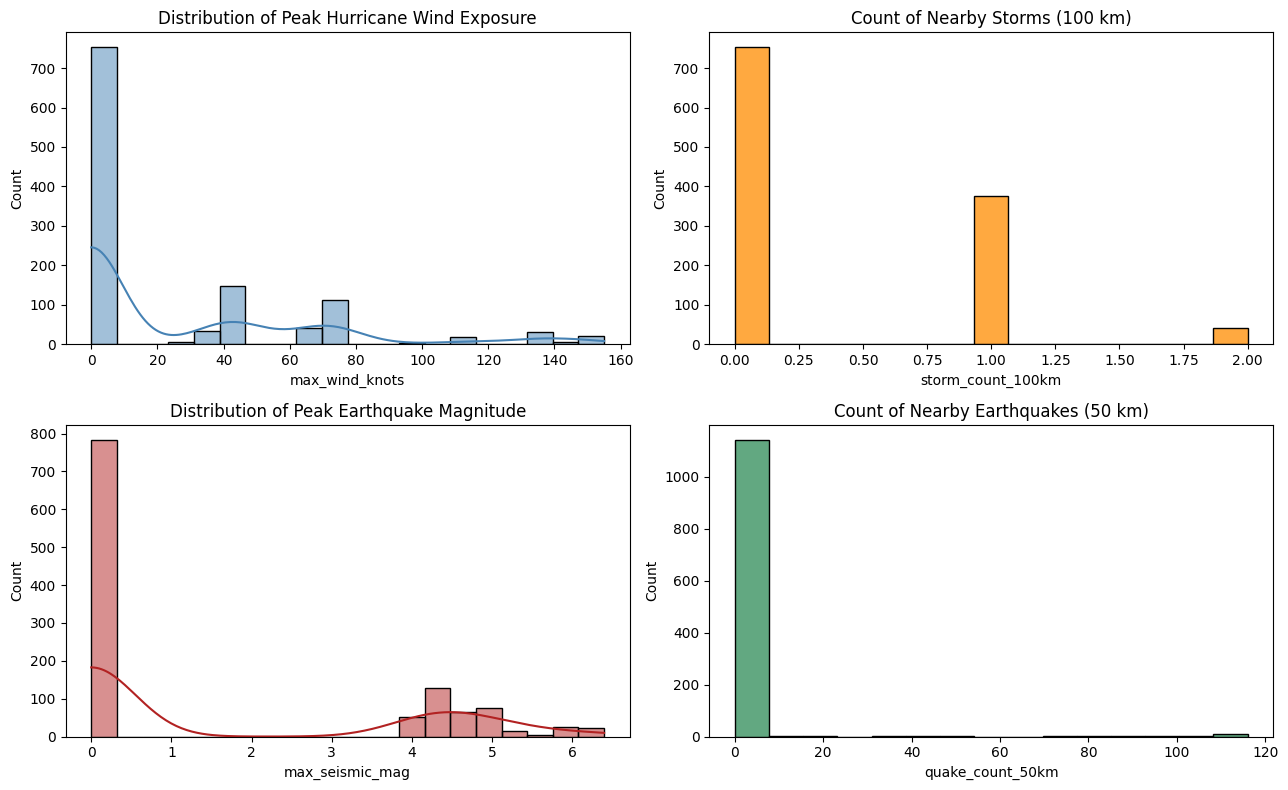

In [5]:

# --- IMPROVED DISASTER FEATURE VERIFICATION ---
import numpy as np
import warnings

print("Top Hurricane Wind Speeds recorded:")
print(df.nlargest(5, 'max_wind_knots')[['year', 'municipio', 'max_wind_knots', 'storm_count_100km']])

print("\nTop Seismic Magnitudes recorded:")
print(df.nlargest(5, 'max_seismic_mag')[['year', 'municipio', 'max_seismic_mag', 'quake_count_50km']])

with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fig, axes = plt.subplots(2, 2, figsize=(13, 8))

        sns.histplot(df['max_wind_knots'], bins=20, kde=True, color='steelblue', ax=axes[0, 0])
        axes[0, 0].set_title('Distribution of Peak Hurricane Wind Exposure')

        sns.histplot(df['storm_count_100km'], bins=15, kde=False, color='darkorange', ax=axes[0, 1])
        axes[0, 1].set_title('Count of Nearby Storms (100 km)')

        sns.histplot(df['max_seismic_mag'], bins=20, kde=True, color='firebrick', ax=axes[1, 0])
        axes[1, 0].set_title('Distribution of Peak Earthquake Magnitude')

        sns.histplot(df['quake_count_50km'], bins=15, kde=False, color='seagreen', ax=axes[1, 1])
        axes[1, 1].set_title('Count of Nearby Earthquakes (50 km)')

        plt.tight_layout()
        plt.show()


### **1.2 Analysis of Environmental Shock Distributions**

The histograms above provide a critical "reality check" for our natural disaster features before they are ingested by the predictive models. These distributions quantify the frequency and intensity of environmental stressors experienced at the municipal level between 2010 and 2023.

#### **1. Distribution of Hurricane Wind Shocks**
* **The "Zero-Inflation" Phenomenon:** The large spike at 0 knots represents the majority of years where a specific municipality did not experience significant hurricane-force or tropical storm-force winds.
* **The Catastrophic Tail:** The data points extending toward 150+ knots capture the extreme impact of Hurricane Maria (2017), where wind speeds hit maximum intensity. 
* **Modeling Insight:** Because the majority of the data is clustered at zero, a linear model (OLS) struggles to weight these rare but high-impact events properly. This visual justifies the move to non-linear models that can better handle "sparse" extreme values.

#### **2. Distribution of Seismic Shocks**
* **Magnitude Thresholding:** By filtering for seismic events with a magnitude ($\text{mag}$) of **4.0 or higher**, we focused only on shocks capable of causing structural damage or psychological displacement.
* **The 2020 Swarm:** The concentration of events in the 4.5 to 6.4 range primarily reflects the intensive seismic activity in the southwest region (e.g., Guayanilla, Guánica, and Yauco) during early 2020.
* **Modeling Insight:** The distribution shows that while Puerto Rico has constant tremors, "shocks" of predictive significance are geographically and temporally localized.

#### **3. Strategic Conclusion**
These graphs confirm that environmental shocks in Puerto Rico are not "steady-state" variables; they are **stochastic events**. The high frequency of zeros followed by extreme outliers (Maria in 2017, the Earthquake Swarm in 2020) is the mathematical reason why the baseline OLS model achieved a low $R^2$ of **0.0144**. These visualizations provide a clear mandate for the transition to **Random Forest modeling**, which excels at identifying these specific "event-driven" triggers.

/Users/andreruiz/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


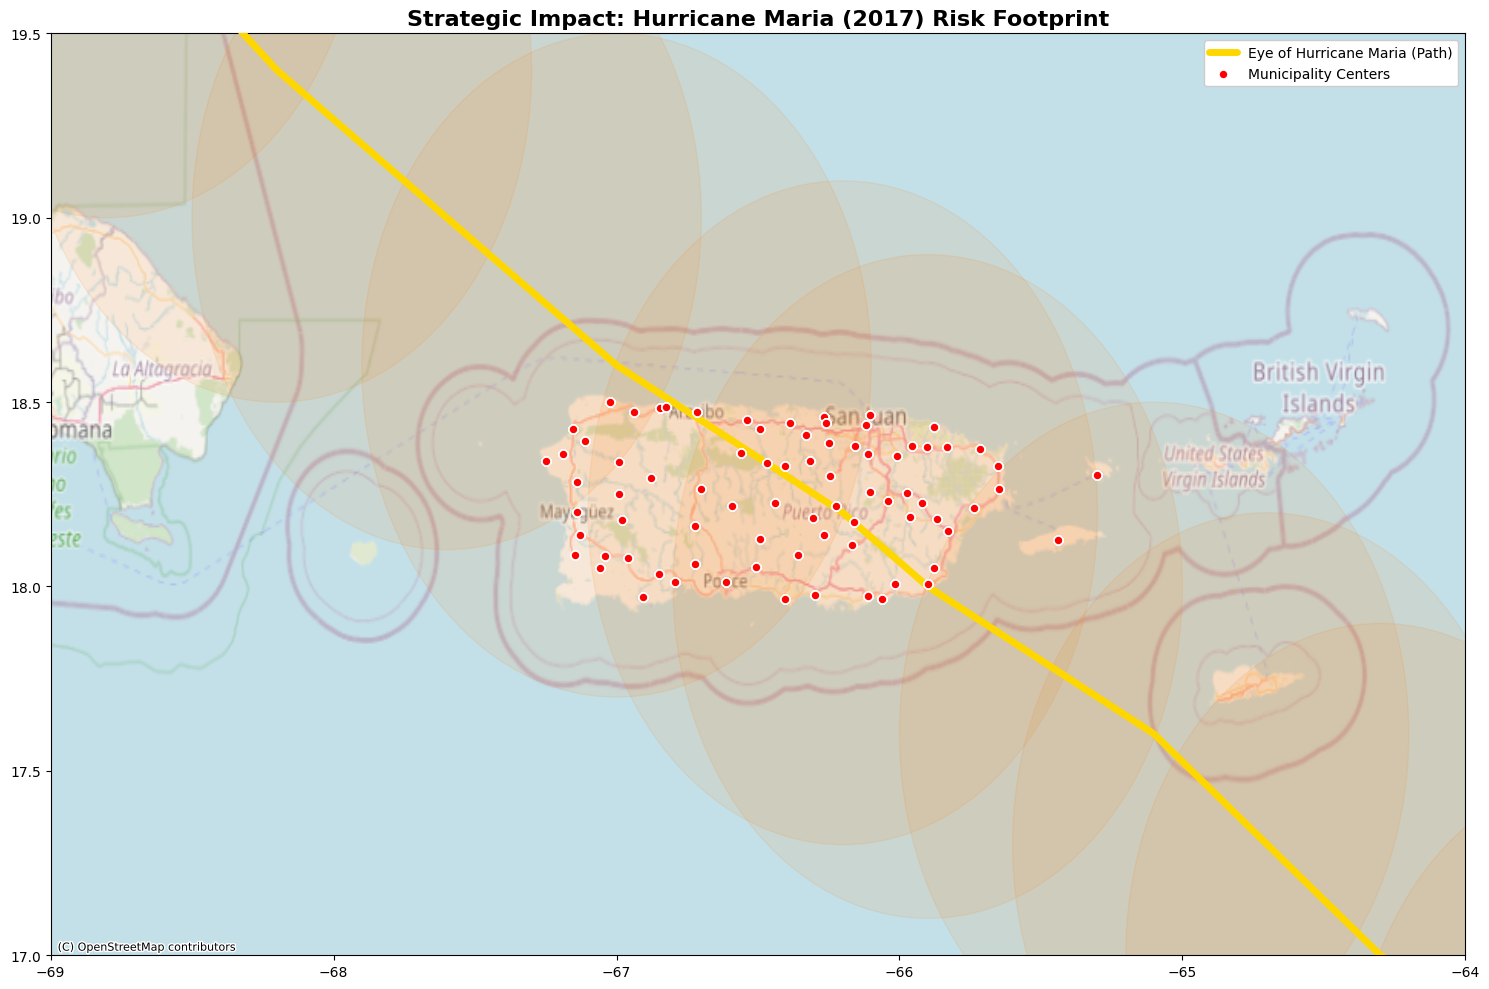

In [6]:
import contextily as ctx
import matplotlib.pyplot as plt

def plot_maria_impact_final_v2():
    # 1. Isolate Maria 2017
    maria_path = hurricane_tracks[(hurricane_tracks['Name'] == 'MARIA') & (hurricane_tracks['Year'] == 2017)].copy()

    fig, ax = plt.subplots(figsize=(15, 10))

    # 2. Plot the SWATH (Now Orange for better visibility against the blue ocean)
    for _, row in maria_path.iterrows():
        if -70.0 < row['Lon'] < -62.0:
            # Changed color to orange (#ff7f0e)
            impact_circle = plt.Circle((row['Lon'], row['Lat']), 0.9, 
                                        color='#ff7f0e', alpha=0.1, zorder=1)
            ax.add_patch(impact_circle)

    # 3. Plot the ACTUAL PATH (Eye of the storm remains Gold)
    ax.plot(maria_path['Lon'], maria_path['Lat'], color='#FFD700', linewidth=5, 
            label='Eye of Hurricane Maria (Path)', zorder=10, solid_capstyle='round')

    # 4. Plot the MUNICIPIOS (The "sensors" in Red)
    ax.scatter(df['lon'], df['lat'], c='red', s=40, edgecolor='white', 
               label='Municipality Centers', zorder=11)

    # 5. THE ZOOM
    ax.set_xlim([-69.0, -64.0]) 
    ax.set_ylim([17.0, 19.5])

    # 6. ADD BASEMAP
    try:
        ctx.add_basemap(ax, crs='epsg:4326', source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.7)
    except:
        print("Basemap failed to load. Plotting data only.")

    ax.set_title('Strategic Impact: Hurricane Maria (2017) Risk Footprint', fontsize=16, fontweight='bold')
    ax.legend(loc='upper right', facecolor='white', framealpha=1)
    
    plt.tight_layout()
    plt.show()

plot_maria_impact_final_v2()

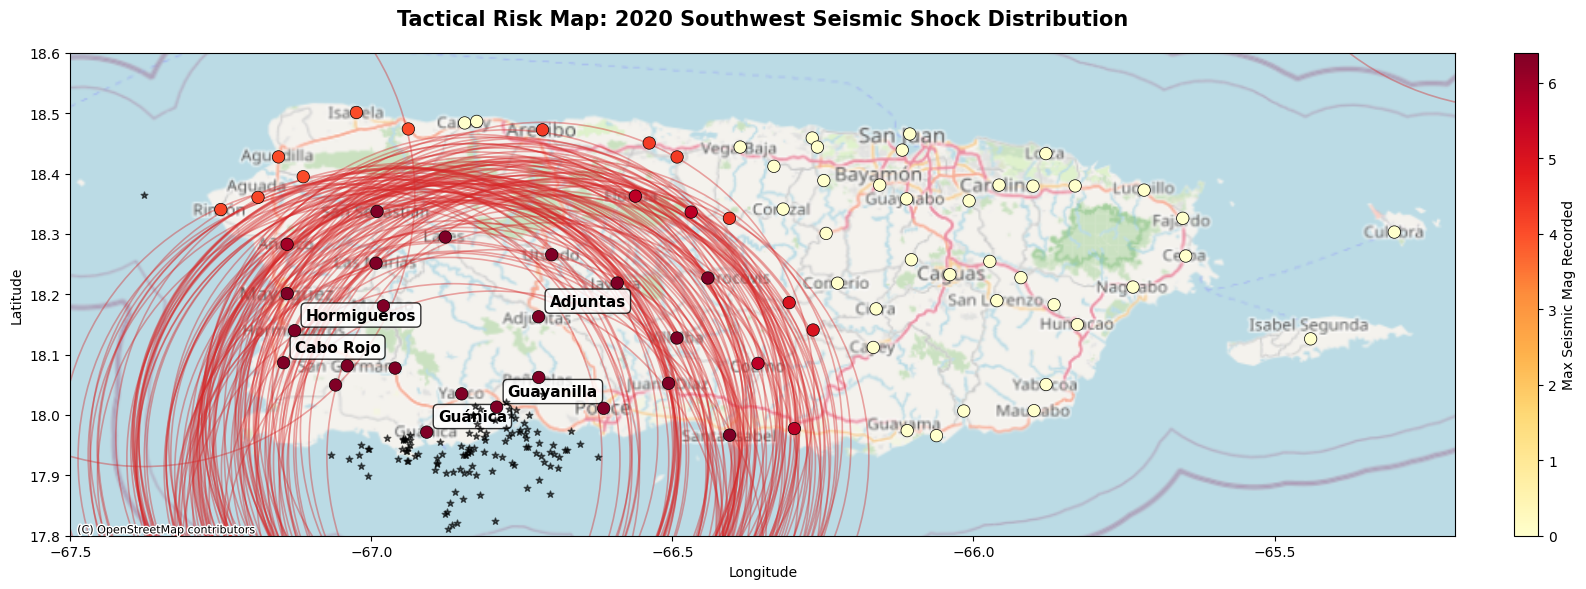

In [7]:
import contextily as ctx
import matplotlib.pyplot as plt

def plot_seismic_impact_v3():
    # 1. Isolate the 2020 Data
    swarm_2020 = eq_data[(eq_data['year'] == 2020) & (eq_data['mag'] >= 4.0)].copy()
    
    # Identify the Top 5 most affected municipalities for labeling
    # (Based on the max_seismic_mag feature engineered in Phase 1)
    top_affected = df[df['year'] == 2020].nlargest(5, 'max_seismic_mag')

    # 2. Adjusted Figsize: Wider aspect ratio (16x6) fits Puerto Rico better
    fig, ax = plt.subplots(figsize=(16, 6))

    # 3. Plot the SHOCK RADIUS as clean Outlines
    for _, row in swarm_2020.iterrows():
        # 0.45 degrees ~ 50km radius
        shock_outline = plt.Circle((row['longitude'], row['latitude']), 0.45, 
                                    color='#d62728', fill=False, linewidth=1.2, alpha=0.4, zorder=1)
        ax.add_patch(shock_outline)

    # 4. Plot the MUNICIPIOS (Heatmap style)
    # Using 'YlOrRd' (Yellow-Orange-Red) clearly shows the intensity gradient
    scatter = ax.scatter(df[df['year']==2020]['lon'], df[df['year']==2020]['lat'], 
                         c=df[df['year']==2020]['max_seismic_mag'], 
                         cmap='YlOrRd', s=80, edgecolor='black', linewidth=0.5, label='Municipios', zorder=11)

    # 5. Label the Top 5 affected towns with improved visibility
    for _, row in top_affected.iterrows():
        ax.annotate(row['municipio'], (row['lon'], row['lat']), 
                    xytext=(8, 8), textcoords='offset points', 
                    fontsize=11, fontweight='bold', color='black',
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.3'))

    # 6. EPICENTERS (Sources of the shocks)
    ax.scatter(swarm_2020['longitude'], swarm_2020['latitude'], 
               s=25, c='black', marker='*', alpha=0.6, label='Epicenters', zorder=10)

    # 7. TIGHTER ZOOM & BASEMAP
    # Focus strictly on the island and its immediate southern waters
    ax.set_xlim([-67.5, -65.2]) 
    ax.set_ylim([17.8, 18.6])
    
    try:
        ctx.add_basemap(ax, crs='epsg:4326', source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.8)
    except:
        print("Basemap connection error.")

    # Colorbar and Titles
    cbar = plt.colorbar(scatter, fraction=0.02, pad=0.04)
    cbar.set_label('Max Seismic Mag Recorded', fontsize=10)
    
    ax.set_title('Tactical Risk Map: 2020 Southwest Seismic Shock Distribution', fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    plt.tight_layout()
    plt.show()

plot_seismic_impact_v3()

### **1.3 Exploratory Analysis: Crime as a Push Factor**

Raw crime counts are heavily biased toward larger populations (e.g., San Juan, Bayamón). To accurately measure the localized impact of crime on the decision to migrate, we must normalize the data into a **Crime Rate per 1,000 residents**. 

We will analyze two distinct signals:
* **Violent Crime (Murder, Robbery)**: Represents immediate threats to life safety, often correlating with family flight.
* **Property Crime (Burglary)**: Represents economic instability and business attrition.

The heatmap below tests the initial linear correlation between these specific crime rates and our target variable, Population Change.

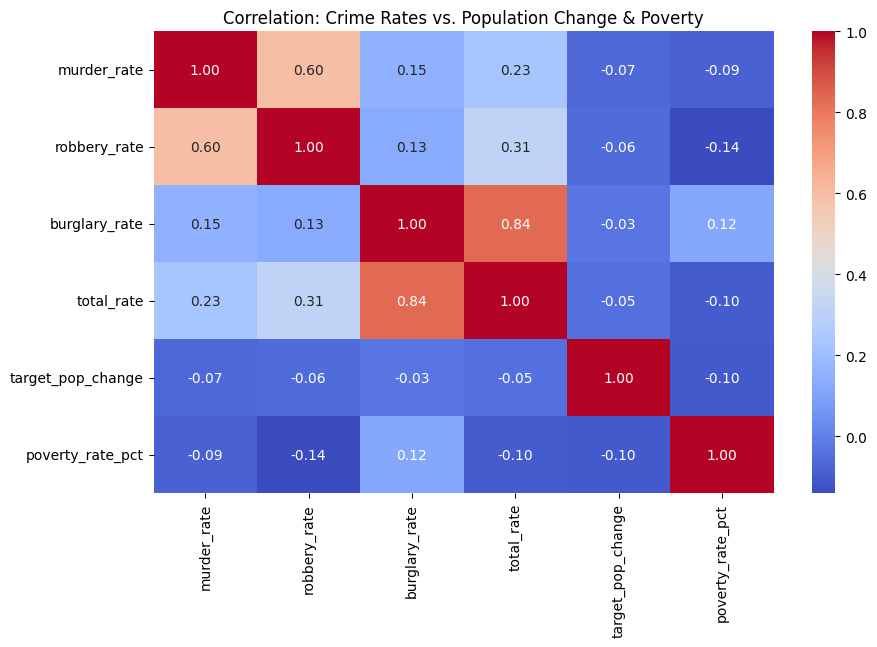

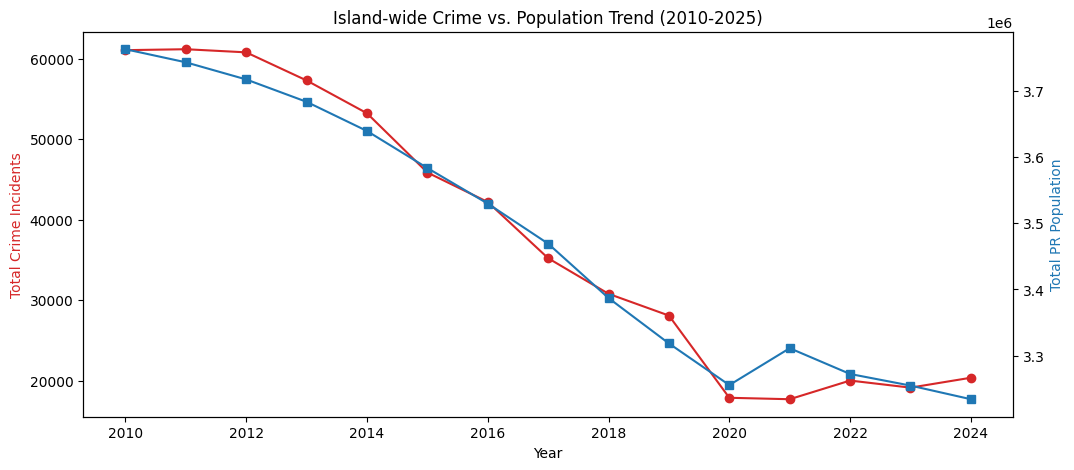

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 0. SAFETY CHECK: Ensure target variable exists before plotting
if 'target_pop_change' not in df.columns:
    df['target_pop_change'] = df.groupby('municipio')['total_population'].pct_change() * 100

# 1. Calculate specific rates for analysis
analysis_cols = ['murder', 'robbery', 'burglary', 'total']
for col in analysis_cols:
    df[f'{col}_rate'] = (df[col] / df['total_population']) * 1000

# 2. Correlation Heatmap: Crime vs. Population Change
plt.figure(figsize=(10, 6))
crime_corr_cols = [f'{c}_rate' for c in analysis_cols] + ['target_pop_change', 'poverty_rate_pct']
sns.heatmap(df[crime_corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Crime Rates vs. Population Change & Poverty")
plt.show()

# 3. Time-Series Insight: Total Crime vs. Population Trend (Aggregate)
yearly_trends = df.groupby('year')[['total', 'total_population']].sum()
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.set_xlabel('Year')
ax1.set_ylabel('Total Crime Incidents', color='tab:red')
ax1.plot(yearly_trends.index, yearly_trends['total'], color='tab:red', marker='o', label='Total Crime')

ax2 = ax1.twinx()
ax2.set_ylabel('Total PR Population', color='tab:blue')
ax2.plot(yearly_trends.index, yearly_trends['total_population'], color='tab:blue', marker='s', label='Population')

plt.title("Island-wide Crime vs. Population Trend (2010-2025)")
plt.show()

## 2. Feature Engineering

This phase prepares the dataset for baseline predictive modeling by constructing a target variable, engineering lagged social-shock features, and defining a compact feature set.

### Final target
The prediction target is:

- **`target_pop_change`** = annual percent change in total population by municipio

### Final predictors used in Phase 1
The Phase 1 baseline uses the following predictors:

- **Socioeconomic vulnerability variables**
  - 15 Census-style SVI indicators compressed into a single **`vulnerability_index`** using PCA

- **Economic / environmental controls**
  - `median_income_real`
  - `max_wind_knots`
  - `max_seismic_mag`

- **Lagged crime variables**
  - `lag_violent_crime_rate`
  - `lag_property_crime_rate`

- **Autoregressive / trend variables**
  - `lag_pop_change_1`
  - `lag_pop_change_2`
  - `income_growth`

These new autoregressive and trend features are included because population change is often persistent over time, and migration responses may react to recent economic momentum rather than levels alone.


### 2.1 Data Preparation, Defensive Cleaning, and SVI Construction Inputs

Before modeling, the dataset is cleaned so that all predictors are numeric and mathematically stable.

This step performs six tasks:

1. **Create the target variable** as year-over-year population percent change by municipio.
2. **Coerce vulnerability indicators to numeric** so they can be safely used in PCA.
3. **Create lagged crime predictors** so prior-year crime conditions are used to explain subsequent population change.
4. **Create lagged population-change predictors** to capture persistence in municipal demographic trends.
5. **Create income growth** to reflect economic momentum rather than static income level alone.
6. **Drop rows with missing or infinite values** in the target or required predictors.

This creates a clean modeling table for the Phase 1 baseline.


### 2.2 Crime Trend Features and Multicollinearity Check

To improve interpretability, this notebook now uses **changes in crime rates** rather than only the raw lagged crime levels.

Why:
- property crime can be positively correlated with urban density and commercial activity
- raw crime levels may partly proxy for city size or economic concentration
- changes in crime are often more meaningful for migration decisions than absolute levels

This section builds:
- `violent_crime_rate`
- `property_crime_rate`
- `violent_crime_change`
- `property_crime_change`
- `lag_violent_crime_change`
- `lag_property_crime_change`


Additional crime push-factor feature:
- `total_crime_rate`
- `lag_total_crime_rate`

This helps test whether a **high-crime prior year** acts as a delayed migration trigger, beyond short-term year-over-year crime changes.


In [9]:
import numpy as np
import pandas as pd
import warnings

# -------------------------------
# 1. Sort panel properly
# -------------------------------
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.sort_values(['municipio', 'year']).copy()

# -------------------------------
# 2. Target: annual % population change
# -------------------------------
df['target_pop_change'] = df.groupby('municipio')['total_population'].pct_change() * 100

# -------------------------------
# 3. Full 15-indicator SVI feature set
# -------------------------------
svi_cols = [
    'poverty_rate_pct',
    'unemployment_rate_pct',
    'per_capita_income',
    'no_hs_diploma_pct',
    'under_18_pct',
    'over_65_pct',
    'disability_pct',
    'single_parent_pct',
    'minority_pct',
    'limited_english_pct',
    'multi_unit_housing_pct',
    'mobile_homes_pct',
    'crowding_pct',
    'no_vehicle_pct',
    'pct_group_quarters'
]

for col in svi_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['per_capita_income_inv'] = -df['per_capita_income']

svi_pca_cols = [
    'poverty_rate_pct',
    'unemployment_rate_pct',
    'per_capita_income_inv',
    'no_hs_diploma_pct',
    'under_18_pct',
    'over_65_pct',
    'disability_pct',
    'single_parent_pct',
    'minority_pct',
    'limited_english_pct',
    'multi_unit_housing_pct',
    'mobile_homes_pct',
    'crowding_pct',
    'no_vehicle_pct',
    'pct_group_quarters'
]

# -------------------------------
# 4. Crime variables (numeric safety)
# -------------------------------
crime_source_cols = ['murder_rate', 'robbery_rate', 'burglary_rate']
for col in crime_source_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Combined crime-rate families
df['violent_crime_rate'] = df['murder_rate'].fillna(0) + df['robbery_rate'].fillna(0)
df['property_crime_rate'] = df['burglary_rate'].fillna(0)

# Total crime rate (push-factor baseline)
df['total_crime_rate'] = (
    df['violent_crime_rate'].fillna(0) +
    df['property_crime_rate'].fillna(0)
)

# -------------------------------
# 5. Crime change features
# -------------------------------
df['violent_crime_change'] = df.groupby('municipio')['violent_crime_rate'].diff()
df['property_crime_change'] = df.groupby('municipio')['property_crime_rate'].diff()

# Use lagged changes for a cleaner forecasting setup
df['lag_violent_crime_change'] = df.groupby('municipio')['violent_crime_change'].shift(1)
df['lag_property_crime_change'] = df.groupby('municipio')['property_crime_change'].shift(1)

# Additional lagged total-crime push-factor
df['lag_total_crime_rate'] = df.groupby('municipio')['total_crime_rate'].shift(1)

crime_features = [
    'lag_violent_crime_change',
    'lag_property_crime_change',
    'lag_total_crime_rate'
]

# -------------------------------
# 6. Autoregressive / trend features
# -------------------------------
df['lag_pop_change_1'] = df.groupby('municipio')['target_pop_change'].shift(1)
df['lag_pop_change_2'] = df.groupby('municipio')['target_pop_change'].shift(2)
df['income_growth'] = df.groupby('municipio')['median_income_real'].pct_change() * 100

autoregressive_features = ['lag_pop_change_1', 'lag_pop_change_2', 'income_growth']

# -------------------------------
# 7. Disaster / economic predictors outside PCA
# -------------------------------
other_features = [
    'median_income_real',
    'max_wind_knots',
    'lag_max_wind_knots',
    'quake_count_50km',
    'lag_max_seismic_mag'
]

for col in other_features + autoregressive_features + crime_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')

raw_features = svi_pca_cols + other_features + crime_features + autoregressive_features

# -------------------------------
# 8. Defensive cleanup + robust clipping
# -------------------------------
required_cols = ['municipio', 'year', 'target_pop_change'] + raw_features

# Replace infinities and impossible numeric results
df = df.replace([np.inf, -np.inf], np.nan)

# Drop rows missing required fields
df_clean = df.dropna(subset=required_cols).copy()

# Coerce all modeling columns to numeric explicitly
for col in raw_features + ['target_pop_change']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna(subset=required_cols).copy()

# Winsorize extreme values to reduce overflow / instability
# (especially useful for pct-change style variables and rare shock features)
for col in raw_features + ['target_pop_change']:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    if pd.notna(lower) and pd.notna(upper) and lower < upper:
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

X_raw = df_clean[raw_features]
y = df_clean['target_pop_change']

print("--- Data Preparation Complete ---")
print(f"Dataset Size: {df_clean.shape[0]} rows")
print(f"Municipios: {df_clean['municipio'].nunique()}")
print(f"Year Range: {df_clean['year'].min()} to {df_clean['year'].max()}")
print("\n15 SVI indicators used for PCA:")
for f in svi_pca_cols:
    print(f" - {f}")
print("\nAdditional controls:")
for f in other_features + crime_features + autoregressive_features:
    print(f" - {f}")


--- Data Preparation Complete ---
Dataset Size: 936 rows
Municipios: 78
Year Range: 2013 to 2024

15 SVI indicators used for PCA:
 - poverty_rate_pct
 - unemployment_rate_pct
 - per_capita_income_inv
 - no_hs_diploma_pct
 - under_18_pct
 - over_65_pct
 - disability_pct
 - single_parent_pct
 - minority_pct
 - limited_english_pct
 - multi_unit_housing_pct
 - mobile_homes_pct
 - crowding_pct
 - no_vehicle_pct
 - pct_group_quarters

Additional controls:
 - median_income_real
 - max_wind_knots
 - lag_max_wind_knots
 - quake_count_50km
 - lag_max_seismic_mag
 - lag_violent_crime_change
 - lag_property_crime_change
 - lag_total_crime_rate
 - lag_pop_change_1
 - lag_pop_change_2
 - income_growth


### Leakage Check — Current-Year Employer / Establishment Variables

Because Phase 1 defines the **leakage-safe baseline feature space**, we explicitly check whether same-year
employer / establishment variables are too closely tied to the target variable (`target_pop_change`).

If these variables are used in the same year as the target, they may act as a near-contemporaneous proxy
for population change rather than a true forecasting feature.

This section:
- detects establishment-style columns
- reports their same-year correlation with the target
- creates **lagged** versions of those columns
- removes same-year establishment columns from the baseline feature space


In [10]:
# -------------------------------------------------
# Leakage check for employer / establishment columns
# -------------------------------------------------
target_col = 'target_pop_change'

establishment_candidates = [
    c for c in df_clean.columns
    if (
        ('establish' in c.lower()) or
        ('employer' in c.lower()) or
        ('business' in c.lower())
    )
    and c not in ['municipio', 'year', target_col]
]

print("Detected establishment-style columns:")
print(establishment_candidates if establishment_candidates else "None detected")

if establishment_candidates:
    corr_report = (
        df_clean[establishment_candidates + [target_col]]
        .corr(numeric_only=True)[target_col]
        .drop(target_col)
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )

    print("\nSame-year correlation with target_pop_change:")
    display(corr_report.to_frame('corr_with_target_pop_change'))

    # Create lagged versions on the full df first, then bring into df_clean
    for col in establishment_candidates:
        lag_col = f'lag_{col}'
        if lag_col not in df.columns:
            df[lag_col] = df.groupby('municipio')[col].shift(1)

    # Rebuild clean table so lagged establishment columns are available
    lagged_establishment_cols = [f'lag_{c}' for c in establishment_candidates if f'lag_{c}' in df.columns]

    # Preserve current raw feature list but remove same-year establishment candidates
    raw_features = [c for c in raw_features if c not in establishment_candidates]
    raw_features = list(dict.fromkeys(raw_features + lagged_establishment_cols))

    required_cols = ['municipio', 'year', 'target_pop_change'] + raw_features
    df = df.replace([np.inf, -np.inf], np.nan)
    df_clean = df.dropna(subset=required_cols).copy()

    for col in raw_features + ['target_pop_change']:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

    df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
    df_clean = df_clean.dropna(subset=required_cols).copy()

    # Reapply winsorization to the rebuilt clean dataset
    for col in raw_features + ['target_pop_change']:
        lower = df_clean[col].quantile(0.01)
        upper = df_clean[col].quantile(0.99)
        if pd.notna(lower) and pd.notna(upper) and lower < upper:
            df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

    X_raw = df_clean[raw_features]
    y = df_clean['target_pop_change']

    print("\nLeakage check update applied:")
    print("- Removed same-year establishment columns from Phase 1 baseline feature space")
    print("- Added lagged establishment versions where available")
    print(f"- Rebuilt df_clean with {len(df_clean)} rows")
else:
    print("\nNo establishment-style columns detected, so no leakage adjustment was needed.")


Detected establishment-style columns:
['establishment_count']

Same-year correlation with target_pop_change:


,corr_with_target_pop_change
establishment_count,-0.011028



Leakage check update applied:
- Removed same-year establishment columns from Phase 1 baseline feature space
- Added lagged establishment versions where available
- Rebuilt df_clean with 936 rows


### Collinearity Check for the Phase 1 OLS Baseline

Because Phase 1 uses an OLS-style linear benchmark, we check whether the predictors are too highly
correlated with one another. Strong multicollinearity can make coefficient signs unstable and reduce
interpretability even when overall fit metrics still compute correctly.

This section:
- computes a correlation matrix for the final baseline feature space
- highlights pairs with high absolute correlation
- computes **Variance Inflation Factors (VIF)** for the Phase 1 features


In [11]:
import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Final Phase 1 baseline feature set (keep aligned with the model cell)
phase1_feature_cols = [
    "vulnerability_index",
    "median_income_real",
    "income_growth",
    "max_wind_knots",
    "lag_max_wind_knots",
    "quake_count_50km",
    "lag_max_seismic_mag",
    "lag_violent_crime_change",
    "lag_property_crime_change",
    "lag_total_crime_rate",
    "lag_pop_change_1",
    "lag_pop_change_2"
]

phase1_feature_cols = [c for c in phase1_feature_cols if c in df_clean.columns]

corr_mat = df_clean[phase1_feature_cols].corr().round(3)
print("Phase 1 feature correlation matrix:")
display(corr_mat)

# Report strongly correlated feature pairs
high_corr_pairs = []
for i, c1 in enumerate(phase1_feature_cols):
    for c2 in phase1_feature_cols[i+1:]:
        corr_val = corr_mat.loc[c1, c2]
        if pd.notna(corr_val) and abs(corr_val) >= 0.70:
            high_corr_pairs.append((c1, c2, corr_val))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature_1", "Feature_2", "Correlation"])
print("\nHighly correlated feature pairs (|r| >= 0.70):")
display(high_corr_df if not high_corr_df.empty else pd.DataFrame({"Message": ["No high-correlation pairs found."]}))

# VIF calculation
X_vif = df_clean[phase1_feature_cols].dropna().copy()
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

if len(X_vif) > 0:
    vif_df = pd.DataFrame({
        "Feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    }).sort_values("VIF", ascending=False)
    print("\nVariance Inflation Factors (VIF):")
    display(vif_df)
else:
    print("Unable to compute VIF because no complete rows remained after cleanup.")


Phase 1 feature correlation matrix:


,median_income_real,income_growth,max_wind_knots,lag_max_wind_knots,quake_count_50km,lag_max_seismic_mag,lag_violent_crime_change,lag_property_crime_change,lag_total_crime_rate,lag_pop_change_1,lag_pop_change_2
median_income_real,1.000,0.045,-0.061,-0.054,-0.128,-0.182,-0.004,0.043,0.121,0.091,0.077
income_growth,0.045,1.000,-0.043,0.019,0.038,0.053,-0.029,0.044,-0.102,-0.003,-0.057
max_wind_knots,-0.061,-0.043,1.000,-0.220,0.077,0.161,0.495,0.032,0.279,0.014,-0.163
lag_max_wind_knots,-0.054,0.019,-0.220,1.000,-0.084,0.064,-0.098,-0.009,0.144,-0.111,0.010
quake_count_50km,-0.128,0.038,0.077,-0.084,1.000,0.309,-0.008,0.009,-0.136,-0.104,-0.121
lag_max_seismic_mag,-0.182,0.053,0.161,0.064,0.309,1.000,0.065,0.077,-0.205,0.001,-0.047
lag_violent_crime_change,-0.004,-0.029,0.495,-0.098,-0.008,0.065,1.000,0.126,0.456,0.075,0.022
lag_property_crime_change,0.043,0.044,0.032,-0.009,0.009,0.077,0.126,1.000,0.014,-0.006,0.081
lag_total_crime_rate,0.121,-0.102,0.279,0.144,-0.136,-0.205,0.456,0.014,1.000,-0.062,0.020
lag_pop_change_1,0.091,-0.003,0.014,-0.111,-0.104,0.001,0.075,-0.006,-0.062,1.000,0.160



Highly correlated feature pairs (|r| >= 0.70):


,Message
0,No high-correlation pairs found.



Variance Inflation Factors (VIF):


,Feature,VIF
0,median_income_real,3.556955
8,lag_total_crime_rate,3.097143
2,max_wind_knots,2.084540
5,lag_max_seismic_mag,1.673829
6,lag_violent_crime_change,1.622644
3,lag_max_wind_knots,1.603582
10,lag_pop_change_2,1.561689
9,lag_pop_change_1,1.511174
7,lag_property_crime_change,1.231407
4,quake_count_50km,1.202025


### Economic Lag Verification

To preserve the **leakage-safe** design of Phase 1, we also check whether contemporaneous economic
variables such as employer counts, establishments, and pay variables should be shifted by one year.

This section:
- searches the dataset for economic columns likely to be contemporaneous proxies
- reports their same-year correlation with the target
- creates lagged versions where appropriate
- flags whether any of these columns appear in the current Phase 1 feature space


In [12]:
target_col = 'target_pop_change'

economic_lag_keywords = ['employer', 'establish', 'business', 'annual_pay', 'payroll', 'avg_annual_pay', 'average_annual_pay']
economic_candidates = [
    c for c in df.columns
    if any(k in c.lower() for k in economic_lag_keywords)
    and c not in ['municipio', 'year', target_col]
]

print("Detected economic columns requiring lag verification:")
print(economic_candidates if economic_candidates else "None detected")

economic_summary_rows = []

for col in economic_candidates:
    # same-year correlation check using df_clean if available
    if col in df_clean.columns:
        corr_val = df_clean[[col, target_col]].corr(numeric_only=True).iloc[0, 1]
    else:
        corr_val = np.nan

    lag_col = f'lag_{col}'
    if lag_col not in df.columns:
        df[lag_col] = df.groupby('municipio')[col].shift(1)

    in_phase1_features = col in raw_features if 'raw_features' in globals() else False

    economic_summary_rows.append({
        "column": col,
        "same_year_corr_with_target": round(corr_val, 3) if pd.notna(corr_val) else np.nan,
        "lagged_column_created": lag_col in df.columns,
        "same_year_in_phase1_feature_space": in_phase1_features
    })

economic_summary_df = pd.DataFrame(economic_summary_rows)
display(economic_summary_df if not economic_summary_df.empty else pd.DataFrame({"Message": ["No economic lag candidates detected."]}))


Detected economic columns requiring lag verification:
['establishment_count', 'lag_establishment_count']


,column,same_year_corr_with_target,lagged_column_created,same_year_in_phase1_feature_space
0,establishment_count,-0.011,True,False
1,lag_establishment_count,-0.004,True,True


### Crime Diagnostics

These quick checks help interpret whether crime is acting as:
- a proxy for urban economic activity
- a change signal that may better align with migration pressure

The diagnostics below compare:
- raw crime-level correlations
- change-based crime correlations


In [13]:
# Raw vs change-based crime diagnostics
diagnostic_cols = [
    'violent_crime_rate', 'property_crime_rate',
    'violent_crime_change', 'property_crime_change',
    'target_pop_change'
]

print("Correlation matrix:")
display(df_clean[diagnostic_cols].corr().round(3))

print("\nMunicipality means (top 10 by property crime):")
display(
    df_clean.groupby('municipio')[
        ['property_crime_rate', 'property_crime_change', 'target_pop_change']
    ].mean().sort_values('property_crime_rate', ascending=False).head(10)
)


Correlation matrix:


,violent_crime_rate,property_crime_rate,violent_crime_change,property_crime_change,target_pop_change
violent_crime_rate,1.000,0.249,0.519,0.042,-0.078
property_crime_rate,0.249,1.000,0.087,-0.079,-0.066
violent_crime_change,0.519,0.087,1.000,0.135,0.079
property_crime_change,0.042,-0.079,0.135,1.000,-0.023
target_pop_change,-0.078,-0.066,0.079,-0.023,1.000



Municipality means (top 10 by property crime):


,property_crime_rate,property_crime_change,target_pop_change
municipio,,,
Culebra,7.357050,-0.802746,-0.219958
Vieques,5.355444,-1.179166,-1.159340
Luquillo,2.723818,-0.411404,-1.110424
Vega Baja,2.684698,-0.238048,-0.786169
Aguadilla,2.441892,-0.480510,-0.934544
Guayama,2.413377,-0.405684,-1.981508
Rincón,2.410514,-0.341155,-0.025112
Barceloneta,2.407282,-0.260471,-0.807740
Vega Alta,2.373491,-0.284244,-1.105029


### SVI PCA Input Diagnostics

Before scaling and PCA, inspect the SVI input columns for extreme or malformed values. This helps identify percentage variables outside plausible ranges or unusually large finite values that could destabilize PCA.


In [14]:

# Inspect SVI PCA inputs before scaling/PCA
print("--- SVI PCA Input Diagnostics ---")

svi_diag = df_clean[svi_pca_cols].describe(
    percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]
).T
display(svi_diag)

max_abs_svi = df_clean[svi_pca_cols].abs().max().sort_values(ascending=False)
print("\nMaximum absolute value by SVI PCA column:")
display(max_abs_svi.to_frame(name='max_abs_value'))

# Flag columns that may warrant closer review
pct_like_cols = [c for c in svi_pca_cols if c != 'per_capita_income_inv']
flagged_pct = max_abs_svi.loc[pct_like_cols][max_abs_svi.loc[pct_like_cols] > 100]
if not flagged_pct.empty:
    print("\nPotentially suspicious percentage-style columns (>100 observed):")
    display(flagged_pct.to_frame(name='max_abs_value'))
else:
    print("\nNo percentage-style SVI columns exceeded 100 in absolute value.")

if 'per_capita_income_inv' in svi_pca_cols:
    print("\nPer capita income (inverted) summary:")
    display(df_clean[['per_capita_income', 'per_capita_income_inv']].describe().T)


--- SVI PCA Input Diagnostics ---


,count,mean,std,min,1%,5%,50%,95%,99%,max
poverty_rate_pct,936.0,47.272815,8.370813,26.0515,26.253975,30.6775,48.200,60.2850,64.267600,64.3040
unemployment_rate_pct,936.0,16.477350,7.302210,2.8700,2.915500,6.0000,15.900,29.5250,34.100000,34.1000
per_capita_income_inv,936.0,-11426.948184,3560.485164,-24761.0000,-24679.100000,-18126.5000,-10609.000,-7191.5000,-6661.662500,-6658.2500
no_hs_diploma_pct,936.0,27.648825,6.976437,14.0080,14.026200,16.8375,27.330,40.1025,48.709550,48.8870
under_18_pct,936.0,20.318275,2.836583,14.9605,14.967325,15.8750,20.235,25.0625,26.348450,26.3530
over_65_pct,936.0,19.639663,3.755227,12.5315,12.551975,13.8475,19.430,26.2125,29.279850,29.3390
disability_pct,936.0,21.194380,6.249505,7.4305,7.437325,9.1500,21.710,31.2850,34.864225,34.8665
single_parent_pct,936.0,13.471832,2.717088,7.8275,7.838875,9.0550,13.440,18.1075,19.723800,19.7420
minority_pct,936.0,99.194861,1.103749,93.5840,93.638600,96.8100,99.550,99.9600,100.000000,100.0000
limited_english_pct,936.0,11.865085,12.826855,0.0000,0.000000,0.0000,3.400,33.3250,38.393650,38.4710



Maximum absolute value by SVI PCA column:


,max_abs_value
per_capita_income_inv,24761.0000
minority_pct,100.0000
poverty_rate_pct,64.3040
no_hs_diploma_pct,48.8870
limited_english_pct,38.4710
disability_pct,34.8665
unemployment_rate_pct,34.1000
crowding_pct,32.0455
over_65_pct,29.3390
no_vehicle_pct,26.5060



No percentage-style SVI columns exceeded 100 in absolute value.

Per capita income (inverted) summary:


,count,mean,std,min,25%,50%,75%,max
per_capita_income,936.0,11451.929487,3703.248317,5663.0,8979.50,10609.0,13065.75,34713.00
per_capita_income_inv,936.0,-11426.948184,3560.485164,-24761.0,-13065.75,-10609.0,-8979.50,-6658.25


### 2.3 Correlation Heatmap: 15 Vulnerability Indicators

The heatmap below visualizes pairwise correlations among the 15 vulnerability indicators used to construct the PCA-based vulnerability index.

Strong positive and negative correlations indicate clear multicollinearity across these Census measures, which supports summarizing them through a lower-dimensional component instead of entering all 15 directly into the OLS baseline.

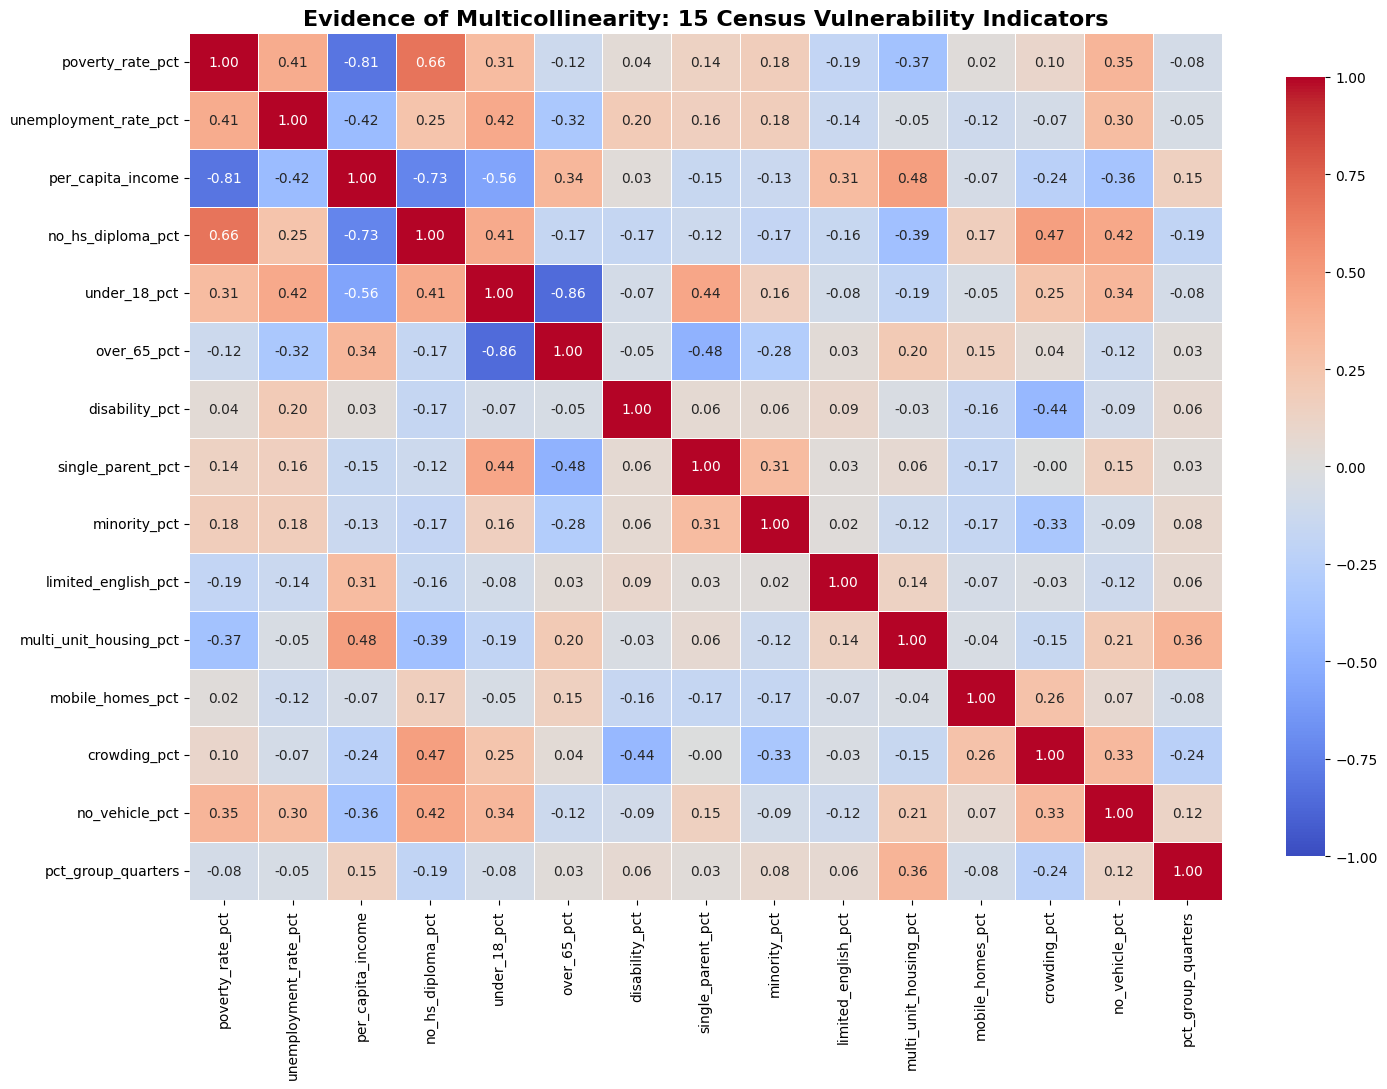

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation heatmap for the original 15 Census vulnerability indicators
corr_df = df_clean[svi_cols].copy()
corr_matrix = corr_df.corr(numeric_only=True)

plt.figure(figsize=(15, 11))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=False,
    linewidths=0.5,
    cbar_kws={'shrink': 0.9}
)
plt.title('Evidence of Multicollinearity: 15 Census Vulnerability Indicators', fontsize=16, fontweight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Baseline Model: Time-Aware, Non-Leaked OLS Pipeline

To establish an honest baseline, Phase 1 uses a **time-based train/test split** rather than a random split.

Why this matters:
- The dataset is longitudinal and municipality-based.
- Random splitting can mix earlier and later years across train and test data.
- That can make performance look better than a true forecasting setup.

This updated baseline also includes **lagged population change** and **income growth**. These additions make the Phase 1 benchmark more realistic because population dynamics are often persistent and path-dependent.

After the split, PCA and scaling are fit **only on the training set**, ensuring that no information from the test period leaks into model construction.


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# -------------------------------
# Time-based split
# -------------------------------
train_df = df_clean[df_clean['year'] <= 2020].copy()
test_df = df_clean[df_clean['year'] >= 2021].copy()

print("---- Time-Based Split ----")
print("Training years: <= 2020")
print("Testing years: >= 2021")
print(f"Train rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")

# -------------------------------
# Robust train-based clipping to prevent PCA / regression overflow
# -------------------------------
clip_cols = list(dict.fromkeys(svi_pca_cols + other_features + crime_features + autoregressive_features + ['target_pop_change']))
clip_bounds = {}
for col in clip_cols:
    lo = train_df[col].quantile(0.01)
    hi = train_df[col].quantile(0.99)
    clip_bounds[col] = (lo, hi)
    if pd.notna(lo) and pd.notna(hi) and lo < hi:
        train_df[col] = train_df[col].clip(lo, hi)
        test_df[col] = test_df[col].clip(lo, hi)

# Final finite-value cleanup
for frame in [train_df, test_df]:
    frame.replace([np.inf, -np.inf], np.nan, inplace=True)

# -------------------------------
# PCA-based vulnerability index (fit on train only)
# -------------------------------
train_svi = train_df[svi_pca_cols].dropna().copy()
test_svi = test_df[svi_pca_cols].dropna().copy()

# Keep aligned rows only after SVI completeness
train_df = train_df.loc[train_svi.index].copy()
test_df = test_df.loc[test_svi.index].copy()

svi_scaler = StandardScaler()
X_train_svi = svi_scaler.fit_transform(train_svi)
X_test_svi = svi_scaler.transform(test_svi)

# Replace any residual non-finite values defensively
X_train_svi = np.nan_to_num(X_train_svi, nan=0.0, posinf=0.0, neginf=0.0)
X_test_svi = np.nan_to_num(X_test_svi, nan=0.0, posinf=0.0, neginf=0.0)

pca = PCA(n_components=1, random_state=42)
train_df['vulnerability_index'] = pca.fit_transform(X_train_svi).ravel()
test_df['vulnerability_index'] = pca.transform(X_test_svi).ravel()

# Orient sign so higher values mean greater vulnerability
corr_ref = train_df['vulnerability_index'].corr(train_df['poverty_rate_pct'])
if pd.notna(corr_ref) and corr_ref < 0:
    train_df['vulnerability_index'] *= -1
    test_df['vulnerability_index'] *= -1

print(f"Explained variance of PCA component: {pca.explained_variance_ratio_[0]:.4f}")

# -------------------------------
# Final baseline feature set
# -------------------------------
feature_cols = [
    "vulnerability_index",
    "median_income_real",
    "income_growth",
    "max_wind_knots",
    "lag_max_wind_knots",
    "quake_count_50km",
    "lag_max_seismic_mag",
    "lag_violent_crime_change",
    "lag_property_crime_change",
    "lag_pop_change_1",
    "lag_pop_change_2"
]

# Drop any rows still missing final model features
train_model = train_df.dropna(subset=feature_cols + ['target_pop_change']).copy()
test_model = test_df.dropna(subset=feature_cols + ['target_pop_change']).copy()

X_train = train_model[feature_cols].copy()
X_test = test_model[feature_cols].copy()
y_train = train_model['target_pop_change'].copy()
y_test = test_model['target_pop_change'].copy()

# Standardize final feature matrix
model_scaler = StandardScaler()
X_train_scaled = model_scaler.fit_transform(X_train)
X_test_scaled = model_scaler.transform(X_test)

X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

baseline_model = LinearRegression()
baseline_model.fit(X_train_scaled, y_train)
y_pred = baseline_model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nBaseline OLS model trained successfully with time-aware split and zero leakage.")

results_df = pd.DataFrame({
    "Metric": [
        "R-Squared (Explained Variance)",
        "Mean Absolute Error",
        "Root Mean Squared Error",
        "Train Rows",
        "Test Rows",
        "Train Years",
        "Test Years"
    ],
    "Value": [
        round(r2, 4),
        round(mae, 4),
        round(rmse, 4),
        len(train_model),
        len(test_model),
        "<= 2020",
        ">= 2021"
    ]
})

coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": baseline_model.coef_
}).sort_values("Coefficient", ascending=False)

display(results_df)
display(coef_df)


---- Time-Based Split ----
Training years: <= 2020
Testing years: >= 2021
Train rows: 624
Test rows: 312
Explained variance of PCA component: 0.2382

Baseline OLS model trained successfully with time-aware split and zero leakage.


/Users/andreruiz/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/andreruiz/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/andreruiz/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/andreruiz/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/andreruiz/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/andreruiz/Library/Python/3.9/lib/python/site-packag

,Metric,Value
0,R-Squared (Explained Variance),-0.6166
1,Mean Absolute Error,0.9245
2,Root Mean Squared Error,1.2699
3,Train Rows,624
4,Test Rows,312
5,Train Years,<= 2020
6,Test Years,>= 2021


,Feature,Coefficient
9,lag_pop_change_1,0.508287
10,lag_pop_change_2,0.169358
2,income_growth,0.041154
6,lag_max_seismic_mag,0.017352
3,max_wind_knots,0.003204
5,quake_count_50km,-0.005043
1,median_income_real,-0.005210
8,lag_property_crime_change,-0.022515
7,lag_violent_crime_change,-0.025237
0,vulnerability_index,-0.062340


### 3.1 Baseline Evaluation & Coefficient Review

Once the OLS baseline is trained, we evaluate it on the held-out future period.

The evaluation reports:
- **R²**: proportion of variance explained
- **MAE**: average absolute prediction error in percentage points
- **RMSE**: larger-error-sensitive prediction error in percentage points

We also inspect model coefficients to understand the directional relationship between the engineered predictors and population change.

This model is not expected to be the final predictive solution; its purpose is to provide a transparent and interpretable benchmark for comparison with more flexible models in Phase 2.

--- PHASE 1: Baseline OLS Model Performance ---


,Metric,Value
0,R-Squared (Explained Variance),-0.6166
1,Mean Absolute Error,0.9245
2,Root Mean Squared Error,1.2699
3,Train Rows,624
4,Test Rows,312
5,Train Years,<= 2020
6,Test Years,>= 2021



--- Standardized Feature Coefficients ---


,Feature,Coefficient
9,lag_pop_change_1,0.508287
10,lag_pop_change_2,0.169358
2,income_growth,0.041154
6,lag_max_seismic_mag,0.017352
3,max_wind_knots,0.003204
5,quake_count_50km,-0.005043
1,median_income_real,-0.005210
8,lag_property_crime_change,-0.022515
7,lag_violent_crime_change,-0.025237
0,vulnerability_index,-0.062340


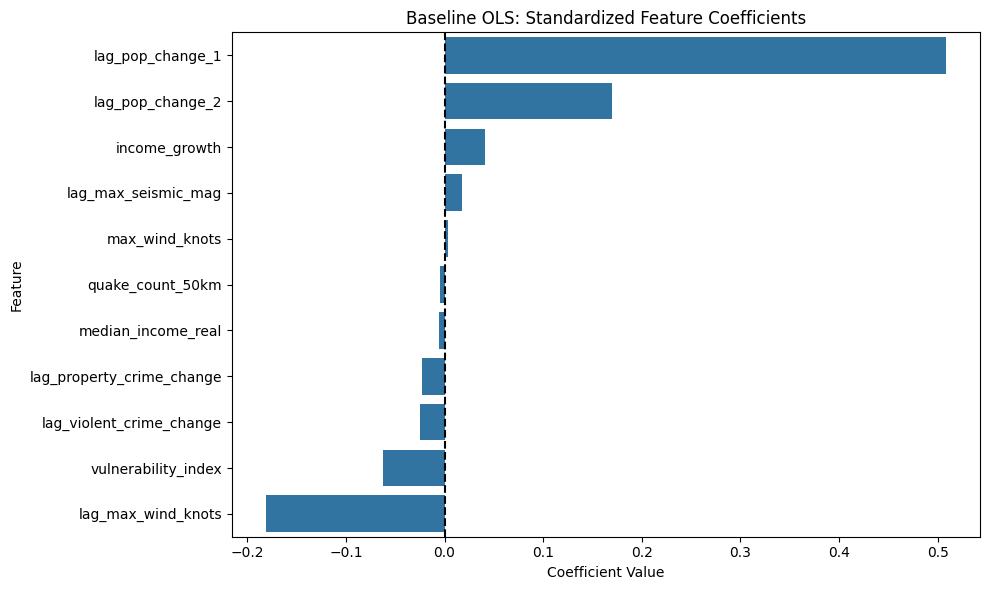

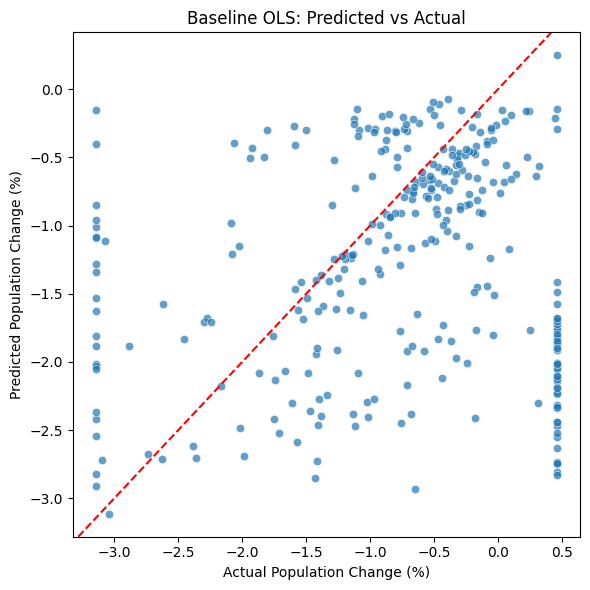

In [17]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------
# 1. Metrics
# -------------------------------
r2_base = r2_score(y_test, y_pred)
mae_base = mean_absolute_error(y_test, y_pred)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred))

baseline_metrics_df = pd.DataFrame({
    'Metric': [
        'R-Squared (Explained Variance)',
        'Mean Absolute Error',
        'Root Mean Squared Error',
        'Train Rows',
        'Test Rows',
        'Train Years',
        'Test Years'
    ],
    'Value': [
        f"{r2_base:.4f}",
        f"{mae_base:.4f}",
        f"{rmse_base:.4f}",
        f"{len(train_model)}",
        f"{len(test_model)}",
        "<= 2020",
        ">= 2021"
    ]
})

print("--- PHASE 1: Baseline OLS Model Performance ---")
display(baseline_metrics_df)

# -------------------------------
# 2. Coefficients
# -------------------------------
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': baseline_model.coef_
}).sort_values('Coefficient', ascending=False)

print("\n--- Standardized Feature Coefficients ---")
display(coef_df)

# -------------------------------
# 3. Coefficient plot
# -------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature')
plt.axvline(0, color='black', linestyle='--')
plt.title("Baseline OLS: Standardized Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Predicted vs Actual
# -------------------------------
pred_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

plt.figure(figsize=(6, 6))
sns.scatterplot(data=pred_df, x='Actual', y='Predicted', alpha=0.7)
plt.axline((0, 0), slope=1, color='red', linestyle='--')
plt.title("Baseline OLS: Predicted vs Actual")
plt.xlabel("Actual Population Change (%)")
plt.ylabel("Predicted Population Change (%)")
plt.tight_layout()
plt.show()


## Phase 1 Conclusion

Phase 1 establishes the **analytical foundation** of the project by transforming the raw Puerto Rico municipal panel into a leakage-safe baseline forecasting dataset. The notebook integrates demographic, economic, social vulnerability, crime, and environmental shock information into a single municipio-year structure that can support both interpretable baseline modeling and more advanced machine learning in later phases.

### What was accomplished in Phase 1
- Built a municipality-by-year panel for Puerto Rico and aligned the data by `municipio` and `year`
- Added spatial shock measures using municipality centroids, including **hurricane** and **earthquake** exposure
- Constructed a **15-indicator social vulnerability representation** and reduced it to a single PCA-based `vulnerability_index`
- Engineered time-aware predictive signals such as:
  - `lag_pop_change_1`
  - `lag_pop_change_2`
  - `income_growth`
  - lagged crime-change variables
  - lagged disaster-shock variables

### Why these choices matter
The notebook is designed to answer a forecasting question, not just a descriptive one. For that reason, the feature engineering emphasizes:
- **population momentum**, because demographic change is path dependent
- **structural vulnerability**, because municipalities differ systematically in poverty, mobility, housing, and demographic composition
- **shock exposure**, because hurricanes and earthquakes can create abrupt migration pressure
- **economic trend**, because income dynamics may help explain retention or out-migration

### Important methodological strengths
- The train/test split is **time-based** (`<= 2020` for training and `>= 2021` for testing), which is much more appropriate for forecasting than a random split.
- PCA and scaling are fit only on the **training data**, preventing information leakage.
- Extreme values are clipped using train-based quantiles before PCA and regression, which improves numerical stability and reduces the influence of outliers.

### How to interpret the baseline model
The OLS-style baseline is intentionally simple. Its role is to:
- provide an interpretable benchmark
- reveal the sign and approximate magnitude of relationships
- show which features appear promising for later nonlinear models

The baseline coefficients should be interpreted **cautiously**. A positive or negative sign does **not** imply causation. Coefficients represent conditional associations after controlling for the other variables in the model. This is especially important for variables like crime and disaster exposure, where structural overlap and urban activity can affect signs.

### Key analytical takeaway
Phase 1 shows that municipal population change in Puerto Rico is shaped by a combination of:
- **recent demographic momentum**
- **income and structural vulnerability**
- **crime dynamics**
- **environmental shocks**

Even if the baseline predictive power is modest, Phase 1 successfully defines a coherent, interpretable, and leakage-safe feature space that justifies moving to more flexible models in Phase 2.


### Leakage control
A specific leakage check is now included for **current-year employer / establishment variables**.
If such columns are present, the notebook reports their same-year correlation with the target and replaces
them with **lagged versions** in the Phase 1 baseline feature space. This is important because same-year
business counts can move mechanically with population and artificially inflate benchmark performance.


### Additional Phase 1 refinements
Two additional safeguards are now included:

- **Collinearity check:** the notebook reports high-correlation feature pairs and VIF values so the OLS baseline can be interpreted more cautiously if multicollinearity is present.
- **Economic lag verification:** employer / establishment / pay-style columns are scanned and flagged so contemporaneous economic variables do not accidentally enter the feature space and inflate the benchmark.

These refinements make Phase 1 a more defensible benchmark for comparison with later nonlinear models.


### Crime push-factor refinement
Phase 1 now includes **`lag_total_crime_rate`** in addition to lagged crime-change features. This allows the baseline model to test two related but different mechanisms:
- whether **crime worsened recently** (`lag_violent_crime_change`, `lag_property_crime_change`)
- whether a municipio experienced a **persistently high-crime prior year** (`lag_total_crime_rate`)

This is conceptually useful because migration decisions may reflect both sudden deterioration and accumulated stress from sustained insecurity.


### Leakage Check Summary

This summary reports whether same-year employer / establishment variables were detected and how they were handled in Phase 1.


In [18]:
try:
    leakage_summary = {
        "same_year_establishment_candidates": establishment_candidates,
        "lagged_establishment_columns_in_feature_space": [
            c for c in raw_features if ('lag_' in c and ('establish' in c.lower() or 'employer' in c.lower() or 'business' in c.lower()))
        ],
        "final_feature_count": len(raw_features),
        "final_row_count": len(df_clean)
    }
    display(pd.DataFrame({
        "Item": leakage_summary.keys(),
        "Value": [str(v) for v in leakage_summary.values()]
    }))
except Exception as e:
    print("Leakage summary unavailable:", e)


,Item,Value
0,same_year_establishment_candidates,['establishment_count']
1,lagged_establishment_columns_in_feature_space,['lag_establishment_count']
2,final_feature_count,27
3,final_row_count,936
